In [1]:
import os
import sys

# This script can be run from the project root or from the notebooks directory.
# If we are in the notebooks directory, we need to add the project root to the path.
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(".."))


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from opt_library.core.centralized.zeroth_order.mezo.mezo import MeZO
from opt_library.core.centralized.zeroth_order.random_search.random_search import (
    RandomSearch,
)
from opt_library.core.centralized.zeroth_order.spsa.spsa import SPSA
from opt_library.core.centralized.zeroth_order.zeroth_order_sgd.zeroth_order_sgd import (
    ZOSGD,
)
from opt_library.core.common.base_problem import (
    ContinuousProblem,
)
from opt_library.simulator.base_logger import ListLogger
from opt_library.simulator.base_stopping_condition import (
    FevalsBudget,
)
from opt_library.simulator.problems import (
    Ackley,
    Beale,
    LinearRegressionProblem,
    Sphere,
)

# ==============================================================================
# Test 1: Synthetic Differentiable Function (Rosenbrock)
# ==============================================================================



In [3]:
class RosenbrockProblem(ContinuousProblem):
    """Rosenbrock function problem."""

    def __init__(self, dim=2):
        super().__init__(bounds=[(-5, 5)] * dim)
        self._dimension = dim

    @property
    def dimension(self) -> int:
        return self._dimension

    def _evaluate(self, x: np.ndarray) -> float:
        """Evaluate the Rosenbrock function."""
        return float(
            np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1 - x[:-1]) ** 2.0)
        )

    def gradient(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient of the Rosenbrock function."""
        xm = x[1:-1]
        xm_m1 = x[:-2]
        xm_p1 = x[2:]
        grad = np.zeros_like(x)
        grad[1:-1] = (
            200 * (xm - xm_m1**2) - 400 * (xm_p1 - xm**2) * xm - 2 * (1 - xm)
        )
        grad[0] = -400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0])
        grad[-1] = 200 * (x[-1] - x[-2] ** 2)
        return grad


def plot_convergence(logs, titles, xlim=None, ylim=None):
    """Plot convergence of algorithms based on function evaluations."""
    plt.figure(figsize=(10, 6))
    for log, title in zip(logs, titles):
        fevals = [item["fevals"] for item in log]
        values = [item["value"] for item in log]
        plt.plot(fevals, values, label=title)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Number of Oracle Calls")
    plt.ylabel("Objective Function Value")
    plt.title("Algorithm Convergence")
    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()



In [4]:
def run_comparison(problem, starting_point, fevals_budget, algorithms):
    """Run comparison of zeroth-order algorithms on a given problem."""
    print(
        f"--- Comparing Zeroth-Order Algorithms on {problem.__class__.__name__} ---"
    )

    logs = []
    titles = []

    for alg_class, params, name in algorithms:
        print(f"Running {name}...")
        problem.reset_fevals()
        logger = ListLogger()
        alg = alg_class(**params)
        alg.fit(
            problem=problem,
            starting_point=starting_point.copy(),
            stopping_condition=FevalsBudget(fevals_budget),
            logger=logger,
        )
        logs.append(logger.get_log())
        titles.append(name)

    # Determine ylim from the collected logs
    max_val = -np.inf
    min_val = np.inf
    for log in logs:
        values = [item["value"] for item in log]
        if values:
            max_val = max(max_val, np.max(values))
            min_val = min(min_val, np.min(values))

    try:
        if np.isinf(max_val) or np.isinf(min_val):
            ylim = None
        else:
            ylim = (min_val - 0.1 * abs(min_val), max_val + 0.1 * abs(max_val))
    except:
        ylim = None

    plot_convergence(logs, titles, xlim=(0, fevals_budget), ylim=ylim)


# ==============================================================================
# Run Comparisons
# ==============================================================================


In [ ]:
# --- Problem 1: Rosenbrock ---
rosenbrock_problem = RosenbrockProblem(dim=2)
starting_point_rosenbrock = np.array([0.0, 0.0])
fevals_budget_rosenbrock = 1000
rosenbrock_algorithms = [
    (RandomSearch, {"num_samples": 20, "search_radius": 1.0}, "Random Search"),
    (ZOSGD, {"learning_rate": 1e-3, "mu": 0.1}, "ZO-SGD (lr=1e-3)"),
    (SPSA, {"a": 1e-3, "c": 0.1}, "SPSA (a=1e-3)"),
    (MeZO, {"learning_rate": 1e-3, "epsilon": 0.1}, "MeZO (lr=1e-3)"),
]
run_comparison(
    rosenbrock_problem,
    starting_point_rosenbrock,
    fevals_budget_rosenbrock,
    rosenbrock_algorithms,
)

In [ ]:

# --- Problem 2: Sphere ---
sphere_problem = Sphere(dim=10)
starting_point_sphere = np.random.uniform(-5.12, 5.12, 10)
fevals_budget_sphere = 2000
sphere_algorithms = [
    (RandomSearch, {"num_samples": 20, "search_radius": 0.5}, "Random Search"),
    (ZOSGD, {"learning_rate": 1e-2, "mu": 0.1}, "ZO-SGD (lr=1e-2)"),
    (SPSA, {"a": 1e-2, "c": 0.1}, "SPSA (a=1e-2)"),
    (MeZO, {"learning_rate": 1e-2, "epsilon": 0.1}, "MeZO (lr=1e-2)"),
]
run_comparison(
    sphere_problem,
    starting_point_sphere,
    fevals_budget_sphere,
    sphere_algorithms,
)

In [ ]:


# --- Problem 3: Beale ---
beale_problem = Beale()
starting_point_beale = np.random.uniform(-4.5, 4.5, 2)
fevals_budget_beale = 1000
beale_algorithms = [
    (RandomSearch, {"num_samples": 20, "search_radius": 1.0}, "Random Search"),
    (ZOSGD, {"learning_rate": 1e-4, "mu": 0.1}, "ZO-SGD (lr=1e-4)"),
    (SPSA, {"a": 1e-4, "c": 0.1}, "SPSA (a=1e-4)"),
    (MeZO, {"learning_rate": 1e-4, "epsilon": 0.1}, "MeZO (lr=1e-4)"),
]
run_comparison(
    beale_problem, starting_point_beale, fevals_budget_beale, beale_algorithms
)


In [ ]:
# --- Problem 4: Ackley ---
ackley_problem = Ackley(dim=2)
starting_point_ackley = np.random.uniform(-5, 5, 2)
fevals_budget_ackley = 3000
ackley_algorithms = [
    (
        RandomSearch,
        {"num_samples": 20, "search_radius": 2.0},
        "Random Search (r=2.0)",
    ),
    (ZOSGD, {"learning_rate": 1e-2, "mu": 0.1}, "ZO-SGD (lr=1e-2)"),
    (
        SPSA,
        {"a": 1e-1, "c": 1.0, "alpha": 0.602, "gamma": 0.101},
        "SPSA (a=1e-1, c=1.0)",
    ),
    (MeZO, {"learning_rate": 1e-1, "epsilon": 1.0}, "MeZO (lr=1e-1, e=1.0)"),
]
run_comparison(
    ackley_problem,
    starting_point_ackley,
    fevals_budget_ackley,
    ackley_algorithms,
)

Running Zeroth-Order Algorithm Comparisons
--- Comparing Zeroth-Order Algorithms on RosenbrockProblem ---
Running Random Search...
Running ZO-SGD (lr=1e-3)...
Running SPSA (a=1e-3)...
Running MeZO (lr=1e-3)...


/tmp/ipykernel_65758/1974458675.py:45: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(*xlim)


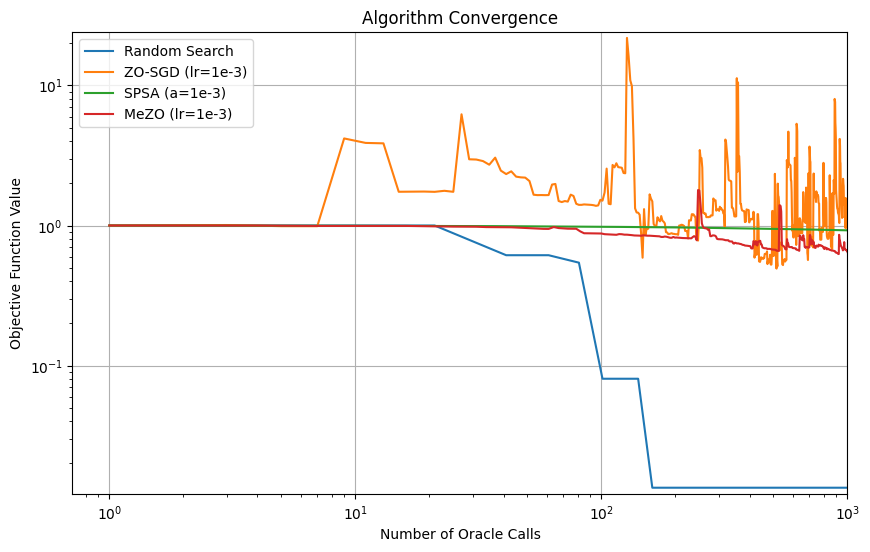

--- Comparing Zeroth-Order Algorithms on Sphere ---
Running Random Search...
Running ZO-SGD (lr=1e-2)...
Running SPSA (a=1e-2)...
Running MeZO (lr=1e-2)...


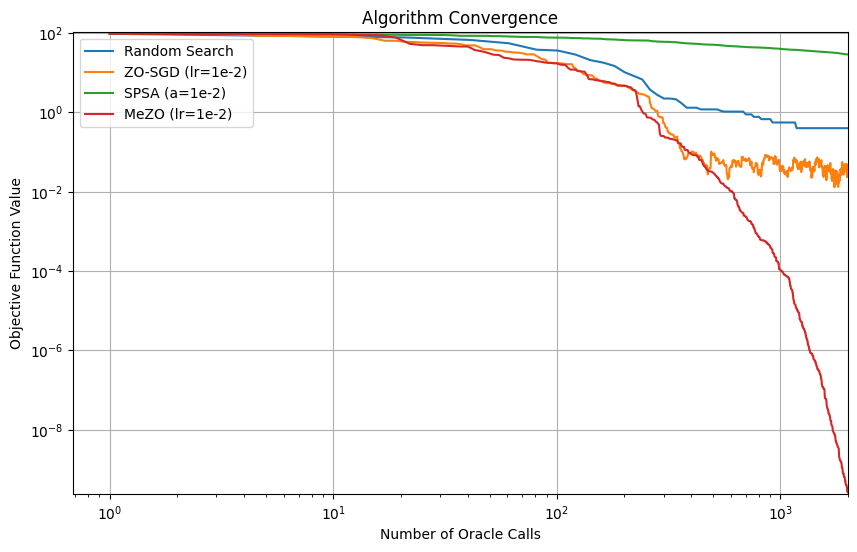

--- Comparing Zeroth-Order Algorithms on Beale ---
Running Random Search...
Running ZO-SGD (lr=1e-4)...
Running SPSA (a=1e-4)...
Running MeZO (lr=1e-4)...


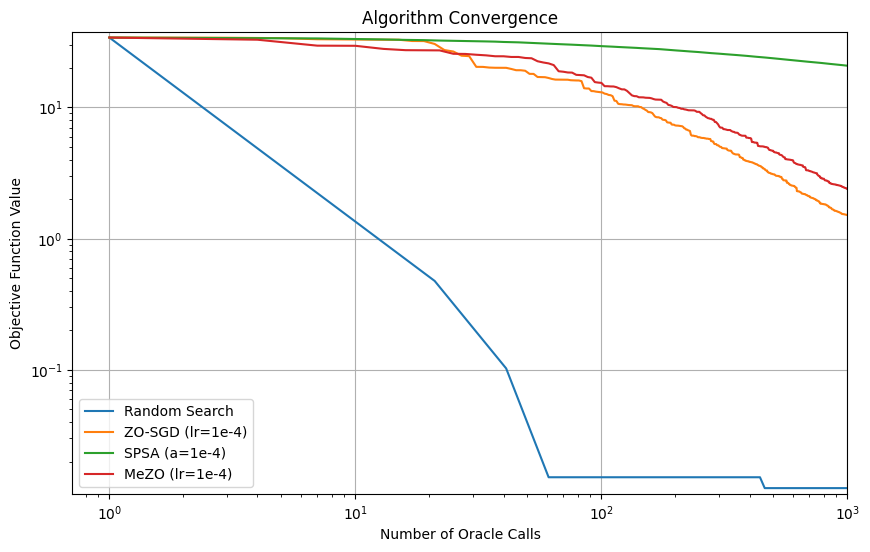

--- Comparing Zeroth-Order Algorithms on Ackley ---
Running Random Search (r=2.0)...
Running ZO-SGD (lr=1e-2)...
Running SPSA (a=1e-1, c=1.0)...
Running MeZO (lr=1e-1, e=1.0)...


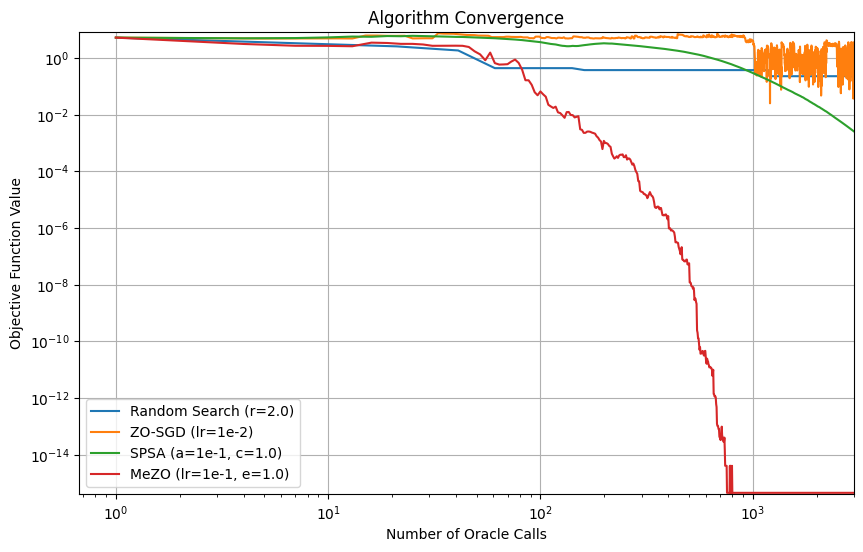

--- Comparing Zeroth-Order Algorithms on LinearRegressionProblem ---
Running Random Search...
Running ZO-SGD...
Running SPSA...
Running MeZO...


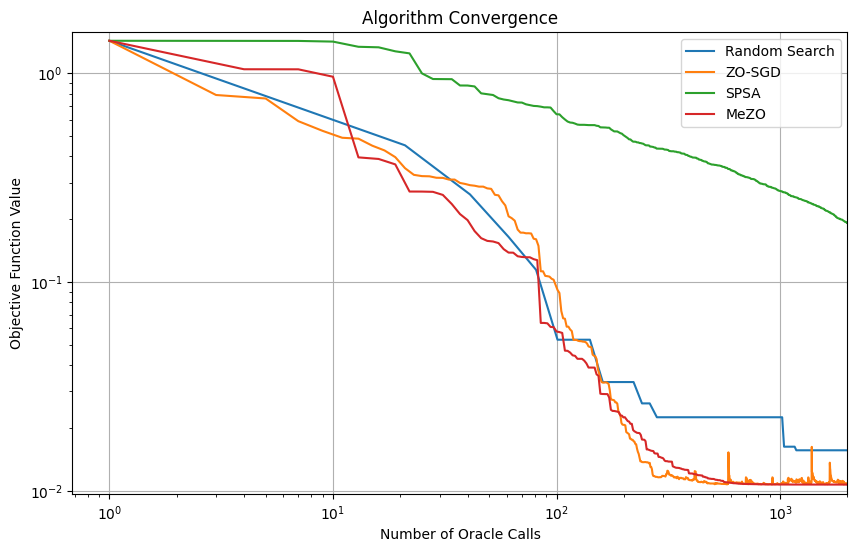

In [ ]:


# --- Problem 5: Linear Regression ---
np.random.seed(42)
n_samples, n_features = 100, 5
X = np.random.rand(n_samples, n_features)
true_w = np.random.randn(n_features)
y = X @ true_w + 0.1 * np.random.randn(n_samples)

lin_reg_problem = LinearRegressionProblem(X, y)
starting_weights = np.zeros(n_features)
fevals_budget_lr = 2000
lr_algorithms = [
    (RandomSearch, {"num_samples": 20, "search_radius": 0.5}, "Random Search"),
    (ZOSGD, {"learning_rate": 0.1, "mu": 0.01}, "ZO-SGD"),
    (SPSA, {"a": 0.1, "c": 0.1}, "SPSA"),
    (MeZO, {"learning_rate": 0.1, "epsilon": 0.1}, "MeZO"),
]
run_comparison(
    lin_reg_problem, starting_weights, fevals_budget_lr, lr_algorithms
)
